# Motion detection in video — `motion_detection`

Detect **activity** (motion) in a video and visualise it **per cell** of a configurable
`GRID_ROWS x GRID_COLS` grid (default 2x2 = the classic 4 quadrants).

This notebook is a self-contained, runnable example for the library function
`saltup.utils.data.video.video_utils.motion_detection`.

## What the function does

1. Reads the video frame by frame (decoding runs in a background thread, overlapping the
   per-frame math).
2. For each pixel it keeps, over a short sliding window, a running mean and a running
   mean-of-squares (exponential moving averages). From these it derives the **temporal
   standard deviation** `std = sqrt(mean(x^2) - mean(x)^2)`: the *temporal movement matrix*
   (high where a pixel keeps changing, ~ noise where it stays static).
3. A pixel is **moving** when its `std` rises above that frame's own noise level (robust
   median + `pixel_k`·MAD). Per cell it finds the **centre of the moving pixels** and
   measures **how far that centre shifts over ~1 s** (in % of the cell size). A pixel
   flickering in place barely moves the centre; something that actually travels reads high.
4. A cell is **active** when that movement crosses `move_threshold` for at least
   `min_seconds` (hysteresis: off below half).

## The output

`motion_detection(path, config)` returns a tuple `(energies, threshold)`:

* `energies` is a **sparse** dict `{frame_index: {quadrant_name: smoothed_movement}}`.
  Only frames in which at least one cell is moving are present, and within such a frame
  only the moving cells appear. The keys are the library quadrant names
  (`quadrant_1`, …, produced by `_quadrant_names`) laid out row-major from the top-left.
* `threshold` is the per-cell turn-on threshold array.

Every knob above is exposed through the `MotionDetectionOptions` dataclass.

In [1]:
import os
import tempfile
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

from saltup.utils.data.video.video_utils import (
    motion_detection,
    process_video,
    get_video_properties,
    VideoReadOptions,
    MotionDetectionOptions,
    _compute_grid,
    _quadrant_names,
)
from saltup.utils.data.image.image_utils import Image

SALTUP_BACKEND set to default mode 'keras_tensorflow'. Using TensorFlow as Keras backend.


## Helpers

Small, dependency-light helpers used throughout the notebook:

* `cell_slices` / `make_grid_visual` — mirror the library's own grid geometry
  (`_compute_grid`, `_quadrant_names`) so the visualisation and the detection always agree.
* `_runs` — turn a boolean mask into a list of `(start, end)` active runs.
* `draw_grid` — draw the cell grid, numbered badges, and a soft highlight on active cells.

In [2]:
def cell_slices(H, W, rows, cols):
    """(y0, y1, x0, x1) for each cell, row-major from the top-left."""
    ys = np.linspace(0, H, rows + 1).round().astype(int)
    xs = np.linspace(0, W, cols + 1).round().astype(int)
    return [(ys[r], ys[r + 1], xs[c], xs[c + 1])
            for r in range(rows) for c in range(cols)]


def make_grid_visual(n_quadrants):
    """Return (rows, cols, names, colors) for an n_quadrants grid."""
    rows, cols = _compute_grid(n_quadrants)
    names = _quadrant_names(n_quadrants)          # "quadrant_1" ... (library keys)
    colors = [plt.cm.tab10(i % 10) for i in range(n_quadrants)]
    return rows, cols, names, colors


def _runs(mask):
    """Compress a boolean array into a list of (start, end) inclusive runs."""
    runs, s = [], None
    for i, m in enumerate(mask):
        if m and s is None:
            s = i
        elif not m and s is not None:
            runs.append((s, i - 1))
            s = None
    if s is not None:
        runs.append((s, len(mask) - 1))
    return runs


def draw_grid(ax, H, W, rows, cols, names, active_mask, colors):
    """Draw the cell grid, numbered badges, and a soft highlight on active cells."""
    ys = np.linspace(0, H, rows + 1)
    xs = np.linspace(0, W, cols + 1)
    for y in ys[1:-1]:
        ax.axhline(y, color="white", lw=0.8, alpha=0.55)
    for x in xs[1:-1]:
        ax.axvline(x, color="white", lw=0.8, alpha=0.55)
    for qi, (y0, y1, x0, x1) in enumerate(cell_slices(H, W, rows, cols)):
        on = (active_mask is None) or bool(active_mask[qi])
        col = colors[qi] if on else (0.62, 0.62, 0.62, 1.0)
        if on and active_mask is not None:
            ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                       fill=True, color=colors[qi], alpha=0.12, lw=0))
            ax.add_patch(plt.Rectangle((x0 + 1, y0 + 1), x1 - x0 - 2, y1 - y0 - 2,
                                       fill=False, edgecolor=colors[qi], lw=2.2))
        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
        ax.text(cx, cy, str(qi + 1), color=col, fontsize=14, fontweight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="circle,pad=0.25", fc="white", ec=col, alpha=0.9, lw=2))

## Example video

To keep the notebook self-contained and reproducible, we synthesise a small clip: a bright
disc travels between the four quadrant centres (so each cell lights up in turn), with a
**stationary idle tail** at the end and a slow **global brightness flicker** across the whole
frame. The flicker is there on purpose — per-cell brightness compensation cancels it, showing
why motion in one cell does not leak into the others.

In [3]:
def make_example_video(path, fps=15, seconds=15, seed=0, W=320, H=240):
    """Write a short synthetic clip: a disc sweeping the quadrants + idle tail + flicker."""
    rng = np.random.default_rng(seed)
    out = cv2.VideoWriter(str(path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))
    n = int(round(fps * seconds))
    qcenters = [(W * 0.25, H * 0.25), (W * 0.75, H * 0.25),
                (W * 0.75, H * 0.75), (W * 0.25, H * 0.75)]
    order = [0, 1, 3, 2, 0]                 # visit quadrant centres in turn
    seg = n // (len(order) - 1)
    positions = []
    for k in range(len(order) - 1):
        ax, ay = qcenters[order[k]]
        bx, by = qcenters[order[k + 1]]
        for f in range(seg):
            t = f / seg
            positions.append((ax + (bx - ax) * t, ay + (by - ay) * t))
    while len(positions) < n:              # pad with a stationary (idle) tail
        positions.append(positions[-1])
    positions = positions[:n]
    for f in range(n):
        flick = int(8 * np.sin(2 * np.pi * f / n))          # global brightness flicker
        frame = np.clip(np.full((H, W), 90 + flick, np.float32), 0, 255).astype(np.uint8)
        x, y = positions[f]
        cv2.circle(frame, (int(round(x)), int(round(y))), 16, 235, -1)
        noise = rng.integers(0, 12, frame.shape).astype(np.int16)
        frame = np.clip(frame.astype(np.int16) + noise, 0, 255).astype(np.uint8)
        out.write(cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR))
    out.release()
    return n

In [4]:
demo_dir = Path(tempfile.mkdtemp(prefix="saltup_motion_"))
VIDEO_PATH = str(demo_dir / "motion_demo.mp4")
n_frames = make_example_video(VIDEO_PATH)

props = get_video_properties(VIDEO_PATH)
print(f"wrote {VIDEO_PATH}")
print(f"properties: {props.fps} fps, {props.total_frames} frames, {props.width}x{props.height}")

wrote /tmp/saltup_motion_rf7v3xde/motion_demo.mp4
properties: 15 fps, 225 frames, 320x240


## Run motion detection

Pass the video to `motion_detection`. With `store=False` (the default is `True`, but the
function only keeps the signal internally) it is cheap and constant-memory — useful for a
first scan. Here we use the defaults and inspect the returned `energies` / `threshold`.

In [5]:
config = MotionDetectionOptions(n_quadrants=4, resize_width=320, verbose=False, window_seconds=0.1, move_threshold=2, pixel_k=1, move_window_sec=0.2, smooth_sec=0.1)
energies, threshold = motion_detection(VIDEO_PATH, config=config)

print(f"returned: energies ({type(energies).__name__}, {len(energies)} active frames), "
      f"threshold shape {tuple(threshold.shape)}")
print("sample entry:", dict(list(energies.items())[:1]))

returned: energies (dict, 219 active frames), threshold shape (4,)
sample entry: {6: {'quadrant_1': 2.4886698722839355}}


## Reconstruct a dense signal from the sparse `energies`

`energies` is sparse (only moving frames / cells). For plotting we rebuild a dense
`(T, n_quadrants)` array of energy values plus an `active` mask, and a matching `times`
vector. `T` here equals the number of frames analysed (contiguous `0..T-1`).

In [6]:
fps = float(config.fps_override) if config.fps_override else float(get_video_properties(VIDEO_PATH).fps)
nq = config.n_quadrants
rows, cols, names, colors = make_grid_visual(nq)

# `energies` is SPARSE: its keys are ABSOLUTE frame indices (0..N-1) and only moving frames
# are present. We rebuild DENSE (T, n_quadrants) arrays indexed by absolute frame number so
# they line up frame-for-frame with the video frames / heatmaps collected below.
frame_indices = sorted(energies.keys())
T_full = frame_indices[-1] + 1
signal = np.zeros((T_full, nq), dtype=float)
active = np.zeros((T_full, nq), dtype=bool)
for fi, entry in energies.items():
    for qi, name in enumerate(names):
        if name in entry:
            signal[fi, qi] = entry[name]
            active[fi, qi] = True
times = np.arange(T_full, dtype=float) / fps
T = T_full

print(f"video frames    : {T}")
print(f"duration        : {times[-1]:.1f} s @ {fps:.1f} fps")
print(f"threshold       : {threshold[0]:.1f}")
print(f"active frames   : {int(active.any(axis=1).sum())} (>=1 cell moving)")
print("per-quadrant active frames:", [int(active[:, qi].sum()) for qi in range(nq)])

video frames    : 225
duration        : 14.9 s @ 15.0 fps
threshold       : 2.0
active frames   : 219 (>=1 cell moving)
per-quadrant active frames: [60, 66, 67, 66]


## Rebuild frames and the heatmap for visualisation

`motion_detection` deliberately returns only the energy *signal* so it stays light; it does
not hand back the per-frame RGB or the temporal-std heatmap. For the visualisation we recompute
those with the **same** preprocessing, reusing the library's `process_video` + `Image`
primitives (we are *not* re-running detection — only reconstructing the visual layers).

In [7]:
def collect_visuals(path, config, fps):
    nq = config.n_quadrants
    r, c = _compute_grid(nq)
    rw = config.resize_width
    N = max(2, int(round(config.window_seconds * fps)))
    alpha = 1.0 / N
    frames_rgb, std_maps = [], []
    state = {"mean": None, "sq": None}

    def cb(img, frame_number, total_frames, meta):
        arr = img.get_data()                              # BGR ndarray
        h0, w0 = arr.shape[:2]
        h = int(round(h0 * rw / w0))
        small = cv2.resize(arr, (rw, h), interpolation=cv2.INTER_AREA)
        gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY).astype(np.float32)
        for (y0, y1, x0, x1) in cell_slices(*gray.shape, r, c):   # per-cell brightness comp
            gray[y0:y1, x0:x1] -= gray[y0:y1, x0:x1].mean()
        if state["mean"] is None:
            state["mean"] = gray.copy()
            state["sq"] = gray * gray
        else:
            cv2.accumulateWeighted(gray, state["mean"], alpha)
            cv2.accumulateWeighted(gray * gray, state["sq"], alpha)
        std_maps.append(np.sqrt(np.clip(state["sq"] - state["mean"] ** 2, 0, None)).astype(np.float32))
        frames_rgb.append(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
        return img

    process_video(path, callback=cb, options=VideoReadOptions(ignore_edit_list=True))
    return np.asarray(frames_rgb), np.asarray(std_maps)


frames_rgb, std_maps = collect_visuals(VIDEO_PATH, config, fps)
# guard against tiny decode-count differences between the two passes
T = min(T, frames_rgb.shape[0], std_maps.shape[0])
signal, active, times = signal[:T], active[:T], times[:T]
print("frames_rgb", frames_rgb.shape, "| std_maps", std_maps.shape)

frames_rgb (225, 240, 320, 3) | std_maps (225, 240, 320)


## Plot 1 — Overview: per-quadrant energy over time

One panel per cell (laid out like the grid), each showing the energy signal, the threshold
(horizontal dashed line) and the frames in which that cell was active (shaded).

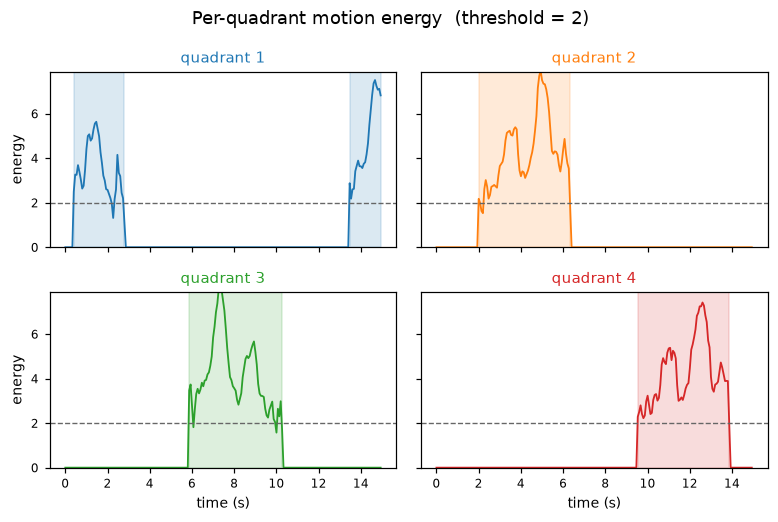

In [8]:
def plot_overview(times, signal, active, threshold, rows, cols, names, colors, title):
    fig, axs = plt.subplots(rows, cols, figsize=(3.6 * cols, 2.4 * rows),
                            sharex=True, sharey=True, squeeze=False)
    for qi in range(rows * cols):
        r, c = divmod(qi, cols)
        ax = axs[r][c]
        ax.plot(times, signal[:, qi], color=colors[qi], lw=1.2)
        ax.axhline(threshold[qi], color="0.4", ls="--", lw=0.9)
        for s, e in _runs(active[:, qi]):
            ax.axvspan(times[s], times[e], color=colors[qi], alpha=0.16)
        ax.set_ylim(0, None)
        ax.set_title(f"quadrant {qi + 1}", fontsize=10, color=colors[qi])
        ax.tick_params(labelsize=8)
        if r == rows - 1:
            ax.set_xlabel("time (s)", fontsize=9)
        if c == 0:
            ax.set_ylabel("energy", fontsize=9)
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()


plot_overview(times, signal, active, threshold, rows, cols, names, colors,
              f"Per-quadrant motion energy  (threshold = {threshold[0]:.0f})")

## Plot 2 — Frame view: video + heatmap + energy cursor

The core "video alongside the plot" view. For a chosen frame it shows:

* **left** — the video frame with the cell grid, numbered badges (coloured when active), and a
  soft highlight on active cells;
* **right** — the temporal-std **heatmap** (same grid);
* **bottom** — the full per-quadrant energy timeline with the threshold, the shaded active
  regions, and a vertical **cursor** pinned to the displayed frame.

This is the plotting strategy for the video: the same frame is read three ways — raw, as
movement heat, and as a point on the energy curve.

first frame with activity: 6 (t = 0.40s)


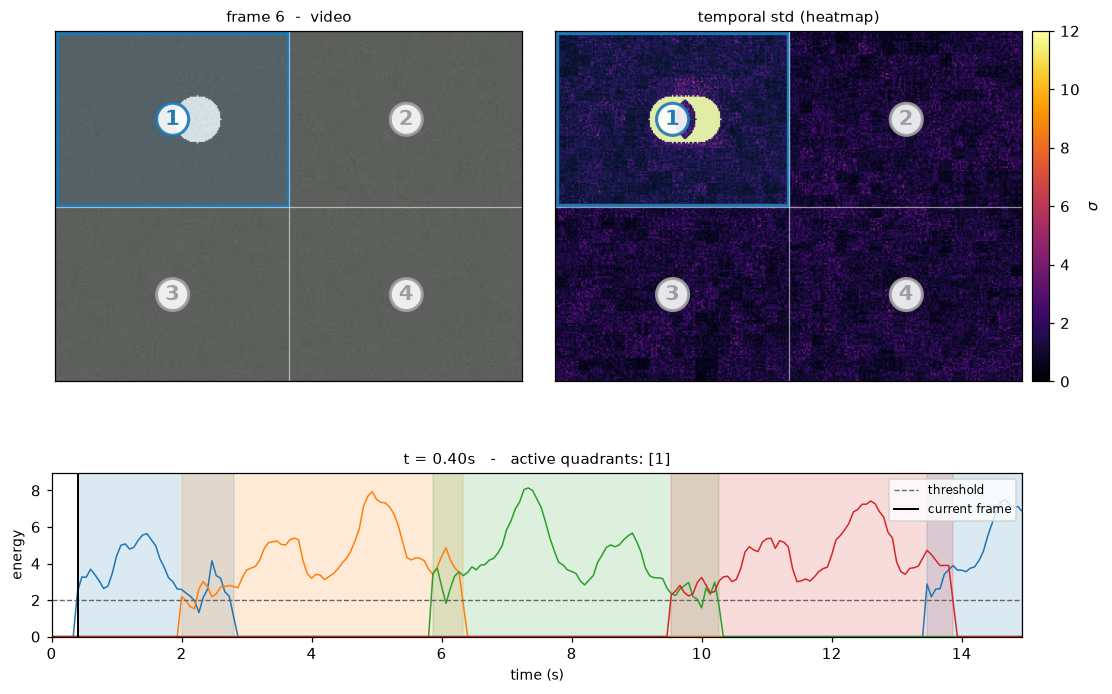

In [9]:
def plot_frame(idx, frames_rgb, std_maps, signal, active, times, threshold,
               rows, cols, colors, heat_vmax=12.0):
    idx = min(idx, frames_rgb.shape[0] - 1)
    fig = plt.figure(figsize=(10, 6.2), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, height_ratios=[3, 1.4], wspace=0.04, hspace=0.18)
    ax_v, ax_h, ax_e = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])
    H, W = frames_rgb[idx].shape[:2]

    ax_v.imshow(frames_rgb[idx]); ax_v.set_xticks([]); ax_v.set_yticks([])
    draw_grid(ax_v, H, W, rows, cols, names, active[idx], colors)
    ax_v.set_title(f"frame {idx}  -  video", fontsize=10)

    im = ax_h.imshow(std_maps[idx], cmap="inferno", vmin=0, vmax=heat_vmax)
    ax_h.set_xticks([]); ax_h.set_yticks([])
    draw_grid(ax_h, H, W, rows, cols, names, active[idx], colors)
    ax_h.set_title("temporal std (heatmap)", fontsize=10)
    fig.colorbar(im, ax=ax_h, fraction=0.046, pad=0.02, label=r"$\sigma$")

    for qi in range(rows * cols):
        ax_e.plot(times, signal[:, qi], color=colors[qi], lw=1.0)
        for s, e in _runs(active[:, qi]):
            ax_e.axvspan(times[s], times[e], color=colors[qi], alpha=0.16)
    ax_e.axhline(threshold[0], color="0.4", ls="--", lw=0.9, label="threshold")
    ax_e.axvline(times[idx], color="black", lw=1.3, label="current frame")
    ax_e.set_xlim(times[0], times[-1])
    ax_e.set_ylim(0, max(signal.max() * 1.1, threshold[0] * 1.3, 1.0))
    ax_e.set_xlabel("time (s)", fontsize=9); ax_e.set_ylabel("energy", fontsize=9)
    ax_e.legend(fontsize=8, loc="upper right")
    on = [qi + 1 for qi in range(rows * cols) if active[idx, qi]]
    ax_e.set_title(f"t = {times[idx]:.2f}s   -   active quadrants: {on if on else 'none'}", fontsize=10)
    plt.show()


first_active = int(np.argmax(active.any(axis=1))) if active.any() else 0
print("first frame with activity:", first_active, f"(t = {times[first_active]:.2f}s)")
plot_frame(first_active, frames_rgb, std_maps, signal, active, times, threshold, rows, cols, colors)

## Montage of representative frames

A static grid of a few representative frames (the start of the first active runs, plus an idle
frame) — handy for notebooks that are exported to static HTML where interactivity is lost.

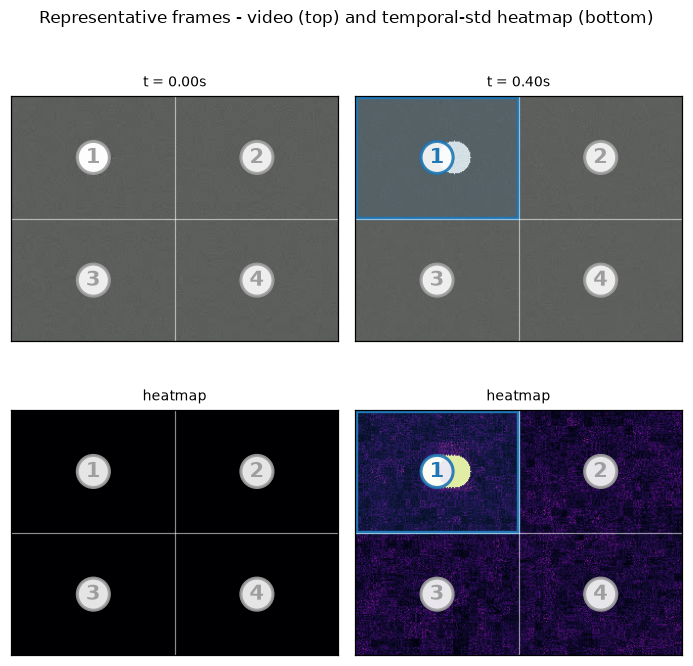

In [10]:
def plot_montage(idxs, frames_rgb, std_maps, active, rows, cols, colors, times, heat_vmax=12.0):
    n = len(idxs)
    fig, axs = plt.subplots(2, n, figsize=(3.2 * n, 6.6), squeeze=False)
    for k, idx in enumerate(idxs):
        idx = min(idx, frames_rgb.shape[0] - 1)
        H, W = frames_rgb[idx].shape[:2]
        axs[0, k].imshow(frames_rgb[idx]); axs[0, k].set_xticks([]); axs[0, k].set_yticks([])
        draw_grid(axs[0, k], H, W, rows, cols, names, active[idx], colors)
        axs[0, k].set_title(f"t = {times[idx]:.2f}s", fontsize=9)
        axs[1, k].imshow(std_maps[idx], cmap="inferno", vmin=0, vmax=heat_vmax)
        axs[1, k].set_xticks([]); axs[1, k].set_yticks([])
        draw_grid(axs[1, k], H, W, rows, cols, names, active[idx], colors)
        axs[1, k].set_title("heatmap", fontsize=9)
    fig.suptitle("Representative frames - video (top) and temporal-std heatmap (bottom)", fontsize=11)
    fig.tight_layout()
    plt.show()


any_active = active.any(axis=1)
runs = _runs(any_active)
rep = [s for (s, e) in runs[:4]]                       # start of first few active runs
idle = next((i for i in range(T) if not any_active[i]), None)
if idle is not None and idle not in rep:
    rep = [idle] + rep
plot_montage(rep[:5], frames_rgb, std_maps, active, rows, cols, colors, times)

## Interactive explorer (optional)

If `ipywidgets` is installed, a slider lets you scrub through every frame and watch the
video / heatmap / energy cursor move together. Without it the notebook still works — the
overview and montage above show the same content.

In [11]:
try:
    from ipywidgets import interact, IntSlider

    @interact(idx=IntSlider(min=0, max=T - 1, step=1, value=first_active, description="frame"))
    def _explore(idx):
        plot_frame(idx, frames_rgb, std_maps, signal, active, times, threshold,
                   rows, cols, colors)
except ImportError:
    print("ipywidgets not installed: skipping the interactive scrubber.")
    print("Install it with `pip install ipywidgets` to scrub frames live.")

interactive(children=(IntSlider(value=6, description='frame', max=224), Output()), _dom_classes=('widget-inter…

## Synchronised player (bonus `.mp4`)

For a shareable artefact we render the whole clip as one compact video: video + heatmap side by
side, with the per-quadrant energy graph underneath and a cursor tracking the current frame.
Encoded with ffmpeg (H.264) when available, otherwise falls back to `mp4v` via OpenCV.

In [12]:
import subprocess, shutil
from IPython.display import Video


def make_player_video(video_path, out_path, times, signal, threshold, active,
                      std_maps, frames_rgb, rows, cols, colors, fps, heat_vmax=12.0):
    T = len(times)
    W = frames_rgb.shape[2]
    bgr = [(int(255 * c[2]), int(255 * c[1]), int(255 * c[0])) for c in colors]

    # 1) render the per-quadrant energy graph once (2*W wide, sits under video+heatmap)
    figp, axp = plt.subplots(figsize=(2 * W / 100.0, 1.9), dpi=100)
    for qi in range(rows * cols):
        axp.plot(times, signal[:, qi], color=colors[qi], lw=0.8)
    axp.axhline(threshold[0], color="k", ls="--", lw=0.8)
    for s, e in _runs(active.any(axis=1)):
        axp.axvspan(times[s], times[e], color="orange", alpha=0.16)
    axp.set_xlim(times[0], times[-1]); axp.set_ylim(0, None); axp.set_yticks([])
    axp.set_xlabel("time (s) - energy per quadrant", fontsize=7); axp.tick_params(labelsize=6)
    figp.subplots_adjust(left=0.01, right=0.999, top=0.97, bottom=0.22)
    figp.canvas.draw()
    strip = np.asarray(figp.canvas.buffer_rgba())[:, :, :3][:, :, ::-1].copy()   # BGR
    bb = axp.get_window_extent(); gx0, gx1 = bb.x0, bb.x1
    plt.close(figp)
    if strip.shape[1] != 2 * W:
        sx = 2 * W / strip.shape[1]
        strip = cv2.resize(strip, (2 * W, int(strip.shape[0] * sx)))
        gx0 *= sx; gx1 *= sx
    SH = strip.shape[0]

    # 2) stream: overlay grid + active borders on [video | heatmap], stack the graph + cursor
    cap = cv2.VideoCapture(video_path)
    use_ff = shutil.which("ffmpeg") is not None
    proc = writer = None
    tmp = out_path + ".mp4v.mp4"
    for i in range(T):
        ok, frame = cap.read()
        if not ok:
            break
        h = frames_rgb.shape[1]
        small = cv2.resize(frame, (W, h), interpolation=cv2.INTER_AREA)
        hm = np.clip(std_maps[i] / heat_vmax * 255, 0, 255).astype(np.uint8)
        heat = cv2.applyColorMap(hm, cv2.COLORMAP_INFERNO)
        ys = np.linspace(0, h, rows + 1).round().astype(int)
        xs = np.linspace(0, W, cols + 1).round().astype(int)
        for panel in (small, heat):
            for y in ys[1:-1]:
                cv2.line(panel, (0, y), (W, y), (255, 255, 255), 1)
            for x in xs[1:-1]:
                cv2.line(panel, (x, 0), (x, h), (255, 255, 255), 1)
        for qi, (y0, y1, x0, x1) in enumerate(cell_slices(h, W, rows, cols)):
            if active[i, qi]:
                cv2.rectangle(small, (x0 + 1, y0 + 1), (x1 - 2, y1 - 2), bgr[qi], 2)
        top = np.hstack([small, heat])
        cur = int(round(gx0 + (i / max(T - 1, 1)) * (gx1 - gx0)))
        si = strip.copy(); cv2.line(si, (cur, 0), (cur, SH - 1), (30, 30, 30), 1)
        comp = np.ascontiguousarray(np.vstack([top, si]))
        if proc is None and writer is None:
            Hc, Wc = comp.shape[:2]
            if use_ff:
                proc = subprocess.Popen(
                    ["ffmpeg", "-y", "-f", "rawvideo", "-pix_fmt", "bgr24", "-s", f"{Wc}x{Hc}",
                     "-r", f"{fps:.4f}", "-i", "-", "-c:v", "libx264", "-pix_fmt", "yuv420p",
                     "-crf", "30", "-preset", "veryfast", "-loglevel", "error", out_path],
                    stdin=subprocess.PIPE)
            else:
                writer = cv2.VideoWriter(tmp, cv2.VideoWriter_fourcc(*"mp4v"), fps, (Wc, Hc))
        if proc is not None:
            proc.stdin.write(comp.tobytes())
        else:
            writer.write(comp)
    cap.release()
    if proc is not None:
        proc.stdin.close(); proc.wait()
    elif writer is not None:
        writer.release(); os.replace(tmp, out_path)
    return T


player_path = str(Path(VIDEO_PATH).parent / "motion_player.mp4")
make_player_video(VIDEO_PATH, player_path, times, signal, threshold, active,
                  std_maps, frames_rgb, rows, cols, colors, fps)
Video(player_path, embed=True)